# LAB 3: Anomaly Detection & Event Intelligence cho chuỗi thời gian IoT

**Bài mẫu:** Ambient Temperature System Failure từ Numenta Anomaly Benchmark (NAB)

Notebook này nối tiếp Lab 2 theo ranh giới rất rõ:

```text
Lab 2 = Data Pipeline
Telemetry thô → schema/cleaning/feature → baseline model → API /predict

Lab 3 = Event Pipeline
Clean telemetry → anomaly_score → event_type → severity → decision → API /detect-anomaly
```

> Ghi nhớ: trong AIoT, `anomaly_score` chưa phải quyết định cuối cùng. Kết quả model cần đi qua event layer, severity và safety rule trước khi cảnh báo hoặc điều khiển thiết bị.


## 0. Chuẩn bị môi trường

Chạy các lệnh sau ở terminal trước khi mở notebook:

```bash
python -m venv .venv
.venv\Scripts\activate        # Windows
source .venv/bin/activate       # macOS/Linux
pip install -r requirements.txt
```

**Cần quan sát gì?**  
Nếu cell import bên dưới chạy không lỗi, nghĩa là môi trường đã sẵn sàng.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from utils import (
    load_dataset, add_time_features, time_split, build_events, evaluate_detection,
    FEATURE_COLUMNS, MODEL_DIR, OUTPUT_DIR, make_windows, save_json, normalize_scores
)

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Môi trường đã sẵn sàng.")


Project root: D:\GIT\lab3_aiot_anomaly_event_intelligence_v3
Môi trường đã sẵn sàng.


## 1. Nạp dataset public

Dataset chính là `ambient_temperature_system_failure.csv` từ NAB. Đây là chuỗi nhiệt độ môi trường trong văn phòng/hệ thống có giai đoạn lỗi.

Notebook có thể chạy theo 2 cách:
1. Nếu đã chạy `python src/download_data.py`, notebook dùng dữ liệu NAB đã tải.
2. Nếu chưa tải được, notebook dùng file sample đi kèm để vẫn học được pipeline.

**Vì sao AIoT cần bước này?**  
Trước khi nói đến model, ta phải biết dữ liệu đến từ đâu, trường nào là timestamp, trường nào là giá trị cảm biến, nhãn anomaly có hay không.

In [2]:
df = load_dataset()
print(df.head())
print("\nSố dòng:", len(df))
print("Cột dữ liệu:", list(df.columns))
print("\nSố điểm được gắn nhãn anomaly:", int(df["label"].sum()))

            timestamp      value  label
0 2013-07-04 00:00:00  69.880835      0
1 2013-07-04 01:00:00  71.220227      0
2 2013-07-04 02:00:00  70.877805      0
3 2013-07-04 03:00:00  68.959400      0
4 2013-07-04 04:00:00  69.283551      0

Số dòng: 7267
Cột dữ liệu: ['timestamp', 'value', 'label']

Số điểm được gắn nhãn anomaly: 726


**Cần phân tích sau bước 1**

Trả lời nhanh:
- `timestamp` cho biết điều gì?
- `value` là cảm biến gì?
- `label = 1` có nghĩa là gì?
- Nếu dataset không có `label`, ta có đánh giá Precision/Recall/F1 được không?

## 2. Quan sát chuỗi thời gian

Trước khi train model, luôn vẽ dữ liệu.

**Vì sao?**  
Dữ liệu IoT là chuỗi thời gian. Nếu không nhìn theo thời gian, sinh viên rất dễ xử lý nó như bảng dữ liệu thông thường và làm sai train/test split.

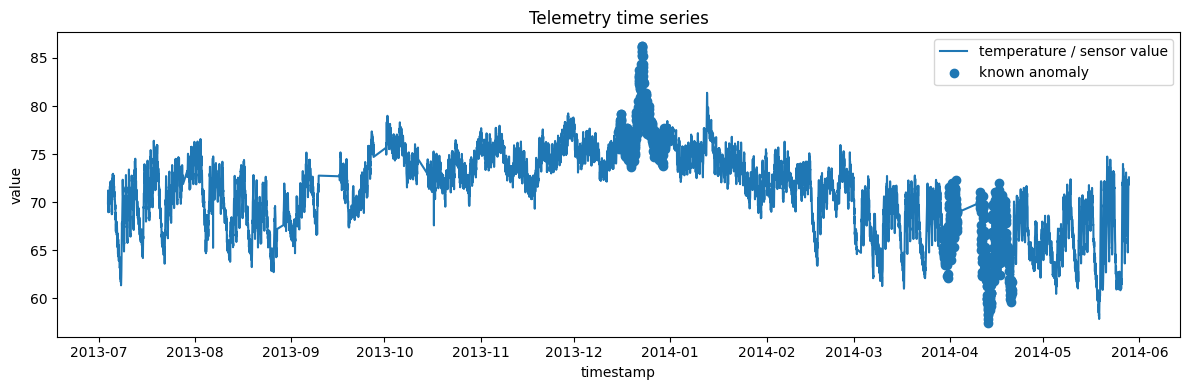

In [3]:
plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["value"], label="temperature / sensor value")
if "label" in df.columns:
    anomalies = df[df["label"] == 1]
    plt.scatter(anomalies["timestamp"], anomalies["value"], label="known anomaly")
plt.title("Telemetry time series")
plt.xlabel("timestamp")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

**Cần quan sát gì?**

- Dữ liệu có biến động theo thời gian không?
- Anomaly là một điểm đơn lẻ hay một đoạn thời gian?
- Nếu chỉ dùng threshold cứng, có dễ báo sai không?

## 3. Tạo feature phục vụ phát hiện bất thường

Ở Lab 2, feature engineering giúp dữ liệu sẵn sàng cho AI nói chung.  
Ở Lab 3, feature được dùng cụ thể để mô tả **hành vi bất thường trong thời gian gần**.

| Feature | Ý nghĩa trong anomaly detection |
|---|---|
| `rolling_mean_12` | hành vi trung bình gần đây |
| `rolling_std_12` | mức dao động gần đây |
| `delta_1` | thay đổi so với điểm trước, hữu ích để phát hiện spike/drop |
| `zscore_rolling` | mức lệch khỏi pattern gần đây |
| `is_stuck_candidate` | nghi ngờ sensor bị đứng |

**Vì sao AIoT cần bước này?**  
Anomaly trong IoT thường không chỉ là “giá trị cao”. Nó còn là “giá trị thay đổi lạ so với lịch sử gần”.


In [4]:
df_feat = add_time_features(df)
df_feat[["timestamp", "value", "rolling_mean_12", "rolling_std_12", "delta_1", "zscore_rolling", "label"]].head(10)

,timestamp,value,rolling_mean_12,rolling_std_12,delta_1,zscore_rolling,label
0,2013-07-04 00:00:00,69.880835,69.880835,0.000000,0.000000,0.000000,0
1,2013-07-04 01:00:00,71.220227,70.550531,0.947093,1.339392,0.707107,0
2,2013-07-04 02:00:00,70.877805,70.659622,0.695842,-0.342422,0.313552,0
3,2013-07-04 03:00:00,68.959400,70.234567,1.022490,-1.918405,-1.247119,0
4,2013-07-04 04:00:00,69.283551,70.044364,0.982344,0.324151,-0.774487,0
5,2013-07-04 05:00:00,70.060966,70.047131,0.878662,0.777415,0.015746,0
6,2013-07-04 06:00:00,69.279765,69.937507,0.852932,-0.781201,-0.771154,0
7,2013-07-04 07:00:00,69.369608,69.866520,0.814788,0.089844,-0.609866,0
8,2013-07-04 08:00:00,69.166714,69.788763,0.797063,-0.202895,-0.780427,0
9,2013-07-04 09:00:00,68.986083,69.708495,0.793189,-0.180631,-0.910770,0


**Cần phân tích sau bước 3**

- `delta_1` cao bất thường gợi ý loại lỗi nào?
- `rolling_std_12` gần 0 trong thời gian dài gợi ý sensor có thể bị gì?
- Vì sao rolling feature giúp model hiểu ngữ cảnh hơn raw value?

## 4. Chia train/test theo thời gian

Với IoT time-series, không random split tùy tiện.

```text
quá khứ → train
tương lai → test
```

**Vì sao?**  
Khi triển khai thật, model chỉ biết dữ liệu quá khứ. Nếu random split, model có thể “nhìn thấy tương lai”, gây đánh giá ảo.

In [5]:
train_df, test_df = time_split(df_feat, train_ratio=0.65)

print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max(), "Số dòng:", len(train_df))
print("Test :", test_df["timestamp"].min(), "→", test_df["timestamp"].max(), "Số dòng:", len(test_df))
print("Anomaly trong train:", int(train_df["label"].sum()))
print("Anomaly trong test :", int(test_df["label"].sum()))

Train: 2013-07-04 00:00:00 → 2014-02-02 13:00:00 Số dòng: 4723
Test : 2014-02-02 14:00:00 → 2014-05-28 15:00:00 Số dòng: 2544
Anomaly trong train: 363
Anomaly trong test : 363


**Checkpoint**

Sinh viên hoàn thành bước này khi giải thích được:
- Train là quá khứ hay tương lai?
- Test là quá khứ hay tương lai?
- Vì sao không nên dùng `train_test_split(..., shuffle=True)` cho dữ liệu IoT?

## 5. Train baseline model: Isolation Forest

Isolation Forest là model anomaly detection nhẹ, thường dùng làm baseline.

**Cách hiểu đơn giản:**  
Model học vùng dữ liệu bình thường. Điểm nào khó giống nhóm bình thường sẽ có `anomaly_score` cao.

**Input model:** các feature trong `FEATURE_COLUMNS`  
**Output model:** điểm bất thường, sau đó ta chuyển thành `anomaly_score` và `is_anomaly`.

In [6]:
train_normal = train_df[train_df["label"] == 0].copy()
if len(train_normal) < 50:
    train_normal = train_df.copy()

iforest = Pipeline([
    ("scaler", StandardScaler()),
    ("detector", IsolationForest(
        n_estimators=200,
        contamination=0.04,
        random_state=42
    ))
])

iforest.fit(train_normal[FEATURE_COLUMNS])

print("Đã train Isolation Forest.")
print("Số dòng dùng để train:", len(train_normal))
print("Feature dùng để train:", FEATURE_COLUMNS)

Đã train Isolation Forest.
Số dòng dùng để train: 4360
Feature dùng để train: ['value', 'hour', 'dayofweek', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_36', 'delta_1', 'delta_3', 'zscore_rolling', 'is_stuck_candidate']


**Cần phân tích sau bước 5**

- Đây có phải forecasting không? Không. Model không dự báo tương lai.
- Model đang học gì? Học vùng dữ liệu bình thường.
- Nếu train data chứa quá nhiều anomaly thì chuyện gì xảy ra?

## 6. Test model và đánh giá bằng metric

Sau khi train, cần test trên dữ liệu chưa dùng để train.

Với anomaly detection có nhãn, ta dùng:
- Precision: cảnh báo anomaly thì đúng bao nhiêu phần?
- Recall: anomaly thật thì bắt được bao nhiêu phần?
- F1-score: cân bằng giữa precision và recall.
- Confusion matrix: xem false alert và missed alert.

**Điểm chuyên nghiệp cần nhớ:**  
Threshold phải được chọn từ dữ liệu train hoặc validation, không chọn trực tiếp từ test. Nếu dùng test để chọn threshold thì kết quả đánh giá sẽ bị lạc quan giả.

**Lưu ý:** MSE không phải metric chính của Isolation Forest. MSE sẽ dùng trong phần Autoencoder vì Autoencoder đo lỗi tái tạo.


In [7]:
# Raw score càng cao thì càng bất thường.
train_raw_scores = -iforest.named_steps["detector"].score_samples(
    iforest.named_steps["scaler"].transform(train_normal[FEATURE_COLUMNS])
)

# Chọn normalization và threshold từ TRAIN để tránh data leakage.
score_min = float(np.min(train_raw_scores))
score_max = float(np.max(train_raw_scores))
train_scores = normalize_scores(train_raw_scores, score_min, score_max)
threshold = float(np.quantile(train_scores, 0.96))

# Test trên dữ liệu tương lai.
test_raw_scores = -iforest.named_steps["detector"].score_samples(
    iforest.named_steps["scaler"].transform(test_df[FEATURE_COLUMNS])
)
anomaly_score = normalize_scores(test_raw_scores, score_min, score_max)

test_result = test_df.copy()
test_result["anomaly_score"] = anomaly_score
test_result["is_anomaly"] = (test_result["anomaly_score"] >= threshold).astype(int)
test_result["model_version"] = "iforest_v2"

metrics = evaluate_detection(test_result["label"], test_result["is_anomaly"])
metrics["threshold"] = float(round(threshold, 4))
metrics["score_min_train"] = float(round(score_min, 6))
metrics["score_max_train"] = float(round(score_max, 6))
metrics["model_type"] = "IsolationForest"
metrics["score_min_train"] = float(round(score_min, 6))
metrics["score_max_train"] = float(round(score_max, 6))
metrics["train_rows"] = int(len(train_df))
metrics["train_normal_rows"] = int(len(train_normal))
metrics["test_rows"] = int(len(test_df))
metrics["model_version"] = "iforest_v2"
metrics["threshold_policy"] = "Threshold lấy từ train_normal, không lấy từ test."
metrics["note"] = "Precision/Recall/F1 chỉ có ý nghĩa khi label anomaly có sẵn."

print(json.dumps(metrics, ensure_ascii=False, indent=2))


{
  "precision": 0.2401,
  "recall": 0.5675,
  "f1_score": 0.3374,
  "confusion_matrix": [
    [
      1529,
      652
    ],
    [
      157,
      206
    ]
  ],
  "tn": 1529,
  "fp": 652,
  "fn": 157,
  "tp": 206,
  "threshold": 0.6091,
  "score_min_train": 0.395053,
  "score_max_train": 0.671542,
  "model_type": "IsolationForest",
  "train_rows": 4723,
  "train_normal_rows": 4360,
  "test_rows": 2544,
  "model_version": "iforest_v2",
  "threshold_policy": "Threshold lấy từ train_normal, không lấy từ test.",
  "note": "Precision/Recall/F1 chỉ có ý nghĩa khi label anomaly có sẵn."
}


**Cần quan sát gì khi test model?**

- Nếu Precision thấp: model cảnh báo quá nhiều điểm sai.
- Nếu Recall thấp: model bỏ sót nhiều anomaly thật.
- Nếu F1 thấp: cần xem lại feature, threshold hoặc dữ liệu train.
- Nếu confusion matrix có nhiều FP, hệ thống thật có thể gây “alert fatigue” cho người vận hành.

## 7. Vẽ anomaly_score và điểm anomaly

Đây là bước rất quan trọng để sinh viên không chỉ nhìn metric mà còn hiểu model đang bắt điểm nào.

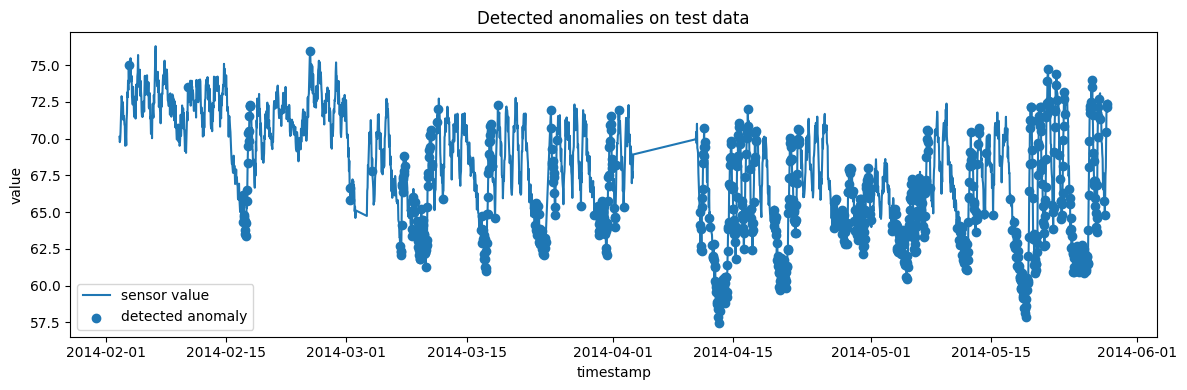

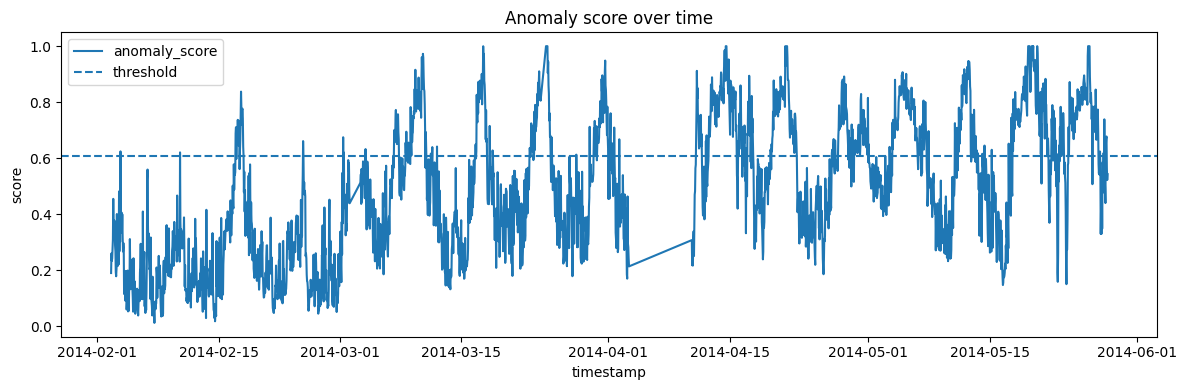

In [8]:
plt.figure(figsize=(12,4))
plt.plot(test_result["timestamp"], test_result["value"], label="sensor value")
detected = test_result[test_result["is_anomaly"] == 1]
plt.scatter(detected["timestamp"], detected["value"], label="detected anomaly")
plt.title("Detected anomalies on test data")
plt.xlabel("timestamp")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(test_result["timestamp"], test_result["anomaly_score"], label="anomaly_score")
plt.axhline(threshold, linestyle="--", label="threshold")
plt.title("Anomaly score over time")
plt.xlabel("timestamp")
plt.ylabel("score")
plt.legend()
plt.tight_layout()
plt.show()

**Cần phân tích sau bước 7**

- Model bắt anomaly ở thời điểm nào?
- Anomaly_score cao nhưng label = 0 có thể là gì?
  - cảnh báo sai,
  - label thiếu,
  - hoặc sự kiện bất thường chưa được ghi nhãn.
- Threshold cao/thấp ảnh hưởng gì đến số cảnh báo?

## 8. Từ model output sang AIoT event

Trong ML notebook, nhiều bạn dừng ở `is_anomaly`.  
Trong AIoT, ta phải biến kết quả đó thành event có cấu trúc.

```text
anomaly_score → threshold → severity → event_type → decision → anomaly_event_log.csv
```

**Ghi nhớ:** `is_anomaly` chưa phải lệnh điều khiển.  
Event layer giúp dashboard/backend hiểu: bất thường loại gì, mức độ nào, cần làm gì.


In [9]:
event_log = build_events(test_result, threshold=threshold)
event_log.head(10)


,timestamp,device_id,value,anomaly_score,threshold_used,severity,event_type,decision,explanation,model_version
0,2014-02-03 16:00:00,nab_office_temp_sensor_01,75.017797,0.6245,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
1,2014-02-10 13:00:00,nab_office_temp_sensor_01,73.548079,0.6209,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
2,2014-02-16 23:00:00,nab_office_temp_sensor_01,64.328171,0.6884,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
3,2014-02-17 00:00:00,nab_office_temp_sensor_01,66.178914,0.7107,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
4,2014-02-17 02:00:00,nab_office_temp_sensor_01,64.790756,0.6697,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
5,2014-02-17 03:00:00,nab_office_temp_sensor_01,64.674285,0.6707,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
6,2014-02-17 04:00:00,nab_office_temp_sensor_01,64.369808,0.6579,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
7,2014-02-17 05:00:00,nab_office_temp_sensor_01,63.500985,0.7370,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
8,2014-02-17 06:00:00,nab_office_temp_sensor_01,63.815341,0.6534,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2
9,2014-02-17 07:00:00,nab_office_temp_sensor_01,64.248089,0.6458,0.6091,MEDIUM,TEMPERATURE_ANOMALY,CREATE_WARNING_EVENT,anomaly score is above operating threshold,iforest_v2


In [10]:
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

model_bundle = {
    "pipeline": iforest,
    "feature_columns": FEATURE_COLUMNS,
    "score_min": score_min,
    "score_max": score_max,
    "threshold": threshold,
    "model_version": "iforest_v2",
    "threshold_policy": "Threshold lấy từ phân bố anomaly_score của train_normal, không lấy từ test."
}

test_result.to_csv(OUTPUT_DIR / "iforest_test_predictions.csv", index=False)
event_log.to_csv(OUTPUT_DIR / "anomaly_event_log.csv", index=False)
joblib.dump(model_bundle, MODEL_DIR / "anomaly_model_bundle_iforest_v2.joblib")
joblib.dump(iforest, MODEL_DIR / "isolation_forest_iforest_v1.joblib")
save_json(metrics, OUTPUT_DIR / "iforest_metrics.json")

print("Đã lưu:")
print("- outputs/iforest_test_predictions.csv")
print("- outputs/anomaly_event_log.csv")
print("- outputs/iforest_metrics.json")
print("- models/anomaly_model_bundle_iforest_v2.joblib")
print("- models/isolation_forest_iforest_v1.joblib")


Đã lưu:
- outputs/iforest_test_predictions.csv
- outputs/anomaly_event_log.csv
- outputs/iforest_metrics.json
- models/anomaly_model_bundle_iforest_v2.joblib
- models/isolation_forest_iforest_v1.joblib


**Cần phân tích sau bước 8**

Mở file `outputs/anomaly_event_log.csv` và trả lời:
- `severity` được dùng để làm gì?
- `decision` khác `is_anomaly` ở điểm nào?
- Vì sao anomaly cao vẫn không nên tự động điều khiển thiết bị?

## 9. Mở rộng khá/giỏi: Neural Autoencoder demo

Phần này giúp sinh viên hiểu hướng dùng mạng neural cho anomaly detection.

**Autoencoder không dự báo tương lai.**  
Nó học cách tái tạo dữ liệu bình thường.

```text
window dữ liệu → autoencoder → window tái tạo → MSE reconstruction error
```

Nếu MSE cao, nghĩa là model tái tạo kém, điểm đó có khả năng bất thường.

**Metric chính ở phần này:** Reconstruction MSE, sau đó chuyển thành anomaly bằng threshold.

In [11]:
window_size = 24

train_normal_values = train_df.loc[train_df["label"] == 0, "value"].values
if len(train_normal_values) < window_size + 10:
    train_normal_values = train_df["value"].values

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_normal_values.reshape(-1, 1)).ravel()
test_scaled = scaler.transform(test_df["value"].values.reshape(-1, 1)).ravel()

X_train = make_windows(train_scaled, window_size=window_size)
X_test = make_windows(test_scaled, window_size=window_size)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, 6, 16),
    activation="relu",
    solver="adam",
    max_iter=250,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=25
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    autoencoder.fit(X_train, X_train)

# Threshold lấy từ reconstruction error trên train windows.
train_reconstructed = autoencoder.predict(X_train)
train_mse = ((X_train - train_reconstructed) ** 2).mean(axis=1)
mse_threshold = float(np.quantile(train_mse, 0.96))

# Test trên dữ liệu tương lai.
reconstructed = autoencoder.predict(X_test)
reconstruction_mse = ((X_test - reconstructed) ** 2).mean(axis=1)
ae_pred = (reconstruction_mse >= mse_threshold).astype(int)

ae_result = test_df.iloc[window_size-1:].copy().reset_index(drop=True)
ae_result["reconstruction_mse"] = reconstruction_mse
ae_result["is_anomaly_ae"] = ae_pred

ae_metrics = evaluate_detection(ae_result["label"], ae_result["is_anomaly_ae"])
ae_metrics["threshold_mse"] = float(round(mse_threshold, 6))
ae_metrics["model_type"] = "MLPRegressor Autoencoder demo"
ae_metrics["window_size"] = int(window_size)
ae_metrics["mse_mean"] = float(round(float(reconstruction_mse.mean()), 6))
ae_metrics["mse_max"] = float(round(float(reconstruction_mse.max()), 6))
ae_metrics["threshold_policy"] = "Threshold MSE lấy từ train windows."
ae_metrics["note"] = "MSE cao nghĩa là model tái tạo window kém, có khả năng bất thường."

print(json.dumps(ae_metrics, ensure_ascii=False, indent=2))

joblib.dump(
    {"scaler": scaler, "autoencoder": autoencoder, "window_size": window_size, "threshold": mse_threshold},
    MODEL_DIR / "mlp_autoencoder_demo.joblib"
)
ae_result.to_csv(OUTPUT_DIR / "autoencoder_test_predictions.csv", index=False)
save_json(ae_metrics, OUTPUT_DIR / "autoencoder_metrics.json")


{
  "precision": 0.1645,
  "recall": 0.1763,
  "f1_score": 0.1702,
  "confusion_matrix": [
    [
      1833,
      325
    ],
    [
      299,
      64
    ]
  ],
  "tn": 1833,
  "fp": 325,
  "fn": 299,
  "tp": 64,
  "threshold_mse": 0.046579,
  "model_type": "MLPRegressor Autoencoder demo",
  "window_size": 24,
  "mse_mean": 0.036253,
  "mse_max": 0.283813,
  "threshold_policy": "Threshold MSE lấy từ train windows.",
  "note": "MSE cao nghĩa là model tái tạo window kém, có khả năng bất thường."
}


**Cần quan sát gì ở Autoencoder?**

- `reconstruction_mse` cao nghĩa là gì?
- MSE ở đây khác MSE trong forecasting như thế nào?
- Nếu tăng threshold thì số cảnh báo tăng hay giảm?
- Autoencoder có dễ giải thích hơn hay khó giải thích hơn Isolation Forest?

## 10. Test model trong notebook khác deploy model như thế nào?

| Giai đoạn | Chạy ở đâu? | Input | Output | Mục tiêu |
|---|---|---|---|---|
| Test model trong notebook | offline | toàn bộ tập test | metric, chart, event log | kiểm tra chất lượng model |
| Deploy model qua API | online/service | một bản tin hoặc một cửa sổ telemetry mới | JSON anomaly event | kiểm tra model có dùng được trong hệ thống AIoT không |

**Câu chốt:**  
Test model trả lời câu hỏi: “model có phát hiện đúng không?”  
Deploy model trả lời câu hỏi: “hệ thống có gọi được model và nhận output đúng format không?”

## 11. Deploy API `/detect-anomaly`

Chạy lệnh sau ở terminal:

```bash
uvicorn src.app:app --reload
```

Mở:

```text
http://127.0.0.1:8000/docs
```

Test bằng terminal khác:

```bash
python src/test_api.py
```

Nếu máy không mở được local port, test logic API bằng:

```bash
python src/test_api_local.py
```

API sẽ trả:

```json
{
  "model_output": {
    "anomaly_score": 0.87,
    "threshold_used": 0.59,
    "is_anomaly": true,
    "model_version": "iforest_v2"
  },
  "event": {
    "event_type": "TEMPERATURE_PATTERN_DEVIATION",
    "severity": "HIGH",
    "decision": "CREATE_ALERT_AND_REQUIRE_HUMAN_CHECK"
  }
}
```


## 12. Phân tích hệ thống sau khi chạy

Sinh viên trả lời vào báo cáo ngắn:

1. Model trong Lab 3 đang phát hiện bất thường theo điểm hay dự báo tương lai?
2. Vì sao cần chia train/test theo thời gian?
3. Precision thấp có thể gây hậu quả gì trong hệ thống thật?
4. Recall thấp có thể gây hậu quả gì?
5. `anomaly_score` khác `decision` như thế nào?
6. Khi deploy API, vì sao response JSON phải có cấu trúc rõ ràng?
7. Khi nào hệ thống chỉ nên cảnh báo thay vì tự điều khiển?
8. Nếu dùng Autoencoder, MSE reconstruction error có ý nghĩa gì?